# Esame Laboratorio di Programmazione II - 14/07/2026

Scrivete chiaramente sul notebook il vostro nome e matricola e salvate il file con il nome della vostra matricola.

Per ogni funzione o metodo che richiede un campionamento rispetto ad una distribuzione, settate il seed a 0: `np.random.seed(0)`.

Stampate il risultato delle domande e consegnate il compito eseguito: ogni cella deve avere il corrispondente output.

Ad esempio, NON scrivete solo:

```python
lista = np.array([1, 2, 3])
```

ma:

```python
lista = np.array([1, 2, 3])
print('lista =', lista)
```


Aggiungete qui sotto il vostro nome e matricola:

**Nome:** [Inserisci il tuo nome]

**Matricola:** [Inserisci la tua matricola] 


In [ ]:
# Qui potete mettere gli import delle librerie


## Esercizio 1

Un amministratore gestisce i seguenti **canoni mensili d'affitto** (in euro) per 10 appartamenti:

`680, 920, 750, 1100, 840, 1250, 700, 980, 620, 1350`

1. Crea un array NumPy `affitti` con questi valori e calcola la **spesa totale mensile**.
2. Gli affitti **minori di 700 euro** ricevono uno **sconto del 10%**. Applica la modifica al vettore.
3. Calcola la nuova spesa totale e il **risparmio totale** ottenuto.


In [12]:
import numpy as np
affitti = np.array([680, 920, 750, 1100, 840, 1250, 700, 980, 620, 1350], dtype=int)
somma_totale = np.sum(affitti)
somma_totale
affitti_scontati = np.where(affitti<700,affitti/100*90,affitti)
affitti_scontati
risparmio=np.sum(affitti-affitti_scontati)
risparmio

np.float64(130.0)

## Esercizio 2

Consideriamo un **random walk** in una dimensione. Ogni camminatore parte da 0; a ogni passo si sposta a destra (`+1`) o a sinistra (`-1`) con uguale probabilità.

1. Scrivi una funzione `random_walk(n_passi, n_camminatori)` che simula il processo e restituisce una matrice NumPy con la posizione cumulativa di ogni camminatore a ogni passo.
2. Simula `200` camminatori per `100` passi e calcola la **posizione media** a ogni passo.
3. Fai un grafico della posizione media in funzione del numero di passi.


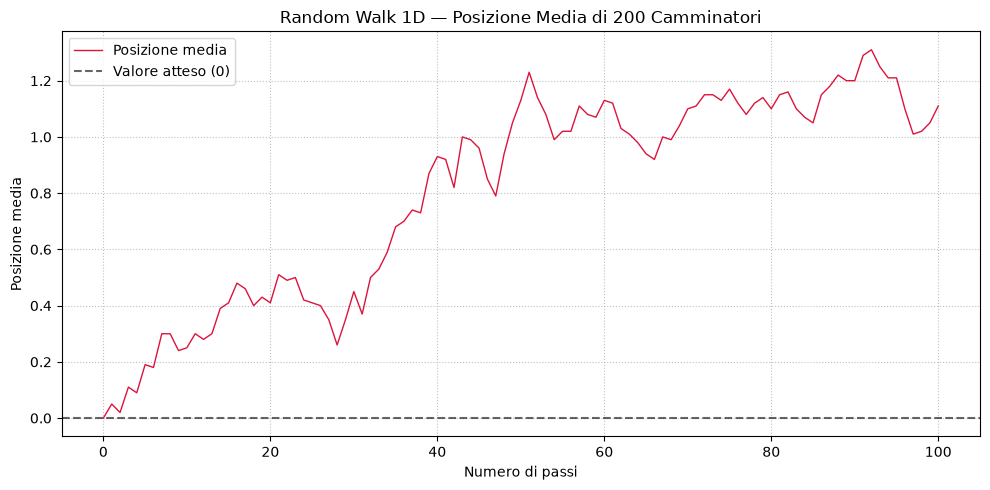

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definizione della funzione per la simulazione del Random Walk
def random_walk(n_passi, n_camminatori):
    # Genera passi +1 o -1 con uguale probabilità (0.5 ciascuno)
    passi = np.random.choice([1, -1], size=(n_camminatori, n_passi))
    
    # Inserisce la posizione di partenza (0) al passo 0
    posizioni_iniziali = np.zeros((n_camminatori, 1), dtype=int)
    passi_totali = np.hstack([posizioni_iniziali, passi])
    
    # Calcola la posizione cumulativa a ogni passo lungo l'asse 1 (passi)
    matrice_posizioni = np.cumsum(passi_totali, axis=1)
    
    return matrice_posizioni

# 2. Simulazione con 200 camminatori e 100 passi
n_camminatori = 200
n_passi = 100

matrice_posizioni = random_walk(n_passi, n_camminatori)

# Calcolo della posizione media a ogni passo (media lungo le colonne / camminatori)
posizione_media = np.mean(matrice_posizioni, axis=0)

# 3. Grafico della posizione media in funzione del numero di passi
plt.figure(figsize=(10, 5))
plt.plot(posizione_media, label='Posizione media', color='crimson', linewidth=1)
plt.axhline(0, color='black', linestyle='--', alpha=0.6, label='Valore atteso (0)')

plt.title('Random Walk 1D — Posizione Media di 200 Camminatori', fontsize=12)
plt.xlabel('Numero di passi')
plt.ylabel('Posizione media')
plt.grid(True, linestyle=':', alpha=0.8)
plt.legend()
plt.tight_layout()

plt.show()

## Esercizio 3

1. Genera una matrice NumPy `A` di dimensioni **5 x 9**, con valori estratti da una distribuzione normale con **media = 10** e **deviazione standard = 4**.
2. Per ogni riga, seleziona il valore **più vicino alla media della riga stessa**. Crea un array con questi 5 valori.
3. Standardizza l'intera matrice sottraendo la media complessiva di `A` e dividendo per la deviazione standard complessiva. Stampa la matrice standardizzata.


In [18]:
import numpy as np

# 1. Generazione della matrice 5x9 (media = 10, deviazione standard = 4)
A = np.random.normal(loc=10, scale=4, size=(5, 9))

# 2. Valore più vicino alla media per ciascuna riga
row_means = A.mean(axis=1, keepdims=True)
closest_indices = np.argmin(np.abs(A - row_means), axis=1)
valori_vicini = A[np.arange(A.shape[0]), closest_indices]

# 3. Standardizzazione dell'intera matrice
A_std = (A - A.mean()) / A.std()

# Stampa dei risultati
print("Matrice A originale:\n", A)
print("\nValori più vicini alla media di ciascuna riga:\n", valori_vicini)
print("\nMatrice A standardizzata:\n", A_std)

Matrice A originale:
 [[ 6.53730333 14.42109226  9.96707788 10.11988197 12.72103722 15.51674282
  17.90684846 11.45708547  6.62446962]
 [14.07116204  8.38437074 14.06231618  2.18975451  9.01630695  6.15992655
   8.99662202 14.70192602  9.70213125]
 [ 7.95890523 12.17755161 16.09458068 11.09086725  7.58125515 11.26290575
  15.06726753  8.69746516 12.46067406]
 [14.99616152  7.17285044  8.28851602  9.73791548  5.74335056 14.02051622
   6.38946028  6.80627396  4.26282053]
 [12.01238504  7.4417975  10.21259232  7.31134764  7.77069791  6.20223341
   6.63398538  9.39195408 10.12106979]]

Valori più vicini alla media di ciascuna riga:
 [11.45708547  9.70213125 11.26290575  8.28851602  7.77069791]

Matrice A standardizzata:
 [[-0.99202591  1.27440014 -0.00603675  0.03789126  0.78566952  1.58937699
   2.27648286  0.42230957 -0.96696741]
 [ 1.17380245 -0.46103228  1.17125945 -2.24185616 -0.27936371 -1.10051392
  -0.28502272  1.35513403 -0.08220342]
 [-0.5833448   0.62942867  1.7554934   0.317029

In [17]:
# =========================
# (Setup) creazione dataset
# =========================
# Eseguire questa cella una volta prima degli esercizi 4 e 5.
import pandas as pd
def make_employees_csv(filename="employees.csv", n=90, seed=12):
    rng = np.random.default_rng(seed)

    employee_id = [f"E{1000+i}" for i in range(n)]
    department = rng.choice(["Sales", "IT", "HR", "Finance", "Operations"], size=n, p=[0.25, 0.25, 0.12, 0.18, 0.20])
    contract = rng.choice(["full_time", "part_time", "intern"], size=n, p=[0.72, 0.20, 0.08])
    experience_years = rng.integers(0, 21, size=n)
    training_hours = rng.integers(0, 81, size=n)

    base_salary = 26000 + experience_years * rng.normal(1450, 220, size=n)
    dept_bonus = pd.Series(department).map({
        "Sales": 2500,
        "IT": 6500,
        "HR": 1200,
        "Finance": 5200,
        "Operations": 2800,
    }).to_numpy()
    salary = np.round(base_salary + dept_bonus + rng.normal(0, 2500, size=n), 2)
    salary = np.clip(salary, 18000, None)

    performance_score = np.round(
        58 + experience_years * 1.1 + training_hours * 0.18 + rng.normal(0, 7, size=n),
        1,
    )
    performance_score = np.clip(performance_score, 35, 100)
    promoted = ((performance_score >= 78) & (experience_years >= 3)).astype(int)

    df = pd.DataFrame({
        "employee_id": employee_id,
        "department": department,
        "contract": contract,
        "experience_years": experience_years,
        "training_hours": training_hours,
        "salary": salary,
        "performance_score": performance_score,
        "promoted": promoted,
    })

    for col in ["department", "contract", "salary", "performance_score"]:
        idx = rng.choice(df.index, size=3, replace=False)
        df.loc[idx, col] = np.nan

    df.to_csv(filename, index=False)
    return df

make_employees_csv()
print("Creato employees.csv")


Creato employees.csv


## Esercizio 4

Si consideri il file CSV `employees.csv`, che contiene informazioni su alcuni dipendenti. Il dataset contiene le colonne:

`employee_id`, `department`, `contract`, `experience_years`, `training_hours`, `salary`, `performance_score`, `promoted`

1. Caricare il dataset in un DataFrame pandas, verificare la presenza di **valori mancanti per colonna** ed eliminare le righe che ne contengono.
2. Creare una nuova colonna `training_efficiency`, definita come:

   $$
   \texttt{training\_efficiency} = \frac{\texttt{performance\_score}}{1 + \texttt{training\_hours}}
   $$

3. Trovare i **10 dipendenti con `training_efficiency` più alta** e stamparli con `employee_id`, `department` e `training_efficiency`.
4. Filtrare i dipendenti con `performance_score >= 80` e `salary < 45000`, e stampare quante righe soddisfano queste condizioni.
5. Creare uno **scatter plot** con `experience_years` sull'asse x, `salary` sull'asse y e `performance_score` come colore dei punti.


## Esercizio 5

Si utilizzi di nuovo il dataset `employees.csv`.

**Prima di svolgere questo esercizio, ricaricare il dataset originale.**

1. Determinare il numero di righe e di colonne del dataset ed eliminare la colonna `employee_id`.
2. Sostituire i valori mancanti nelle colonne categoriche `department` e `contract` con la moda della rispettiva colonna, poi eliminare le righe che contengono ancora valori mancanti.
3. Individuare il `department` più frequente nel dataset.
4. Creare un **boxplot** dei valori di `salary` raggruppati per `contract`
5. Creare un **violin plot** della distribuzione di `performance_score` per ciascun `department`.


## Esercizio 6

Genera due array:

```python
x = np.linspace(0, 10, 100)
y = -2.4 * x + 18 + np.random.normal(0, 3, 100)
```

1. Usare `scipy.optimize.curve_fit` per stimare i parametri `a` e `b` della retta del tipo:

   $$
   y = a \cdot x + b
   $$

2. Plottare i punti originali e la retta ottenuta.
3. Calcolare **MAE** e **RMSE** tra i valori reali `y` e quelli stimati dal modello.


  Using cached scipy-1.18.1-cp313-cp313-win_amd64.whl.metadata (61 kB)
Using cached scipy-1.18.1-cp313-cp313-win_amd64.whl (36.6 MB)
Note: you may need to restart the kernel to use updated packages.


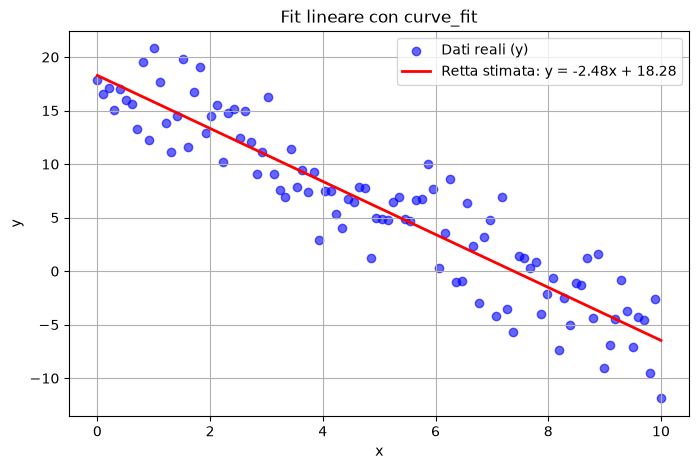

Parametri stimati -> a: -2.4754, b: 18.2821
MAE (Mean Absolute Error): 2.4113
RMSE (Root Mean Squared Error): 2.9656


In [2]:
%pip install scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Generazione dei dati originali
x = np.linspace(0, 10, 100)
y = -2.4 * x + 18 + np.random.normal(0, 3, 100)

# 1. Definizione della funzione modello e stima dei parametri a e b
def retta(x, a, b):
    return a * x + b

popt, _ = curve_fit(retta, x, y)
a_hat, b_hat = popt

# Valori stimati dal modello
y_pred = retta(x, a_hat, b_hat)

# 2. Grafico dei punti originali e della retta interpolante
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label='Dati reali (y)', color='blue', alpha=0.6)
plt.plot(x, y_pred, label=f'Retta stimata: y = {a_hat:.2f}x + {b_hat:.2f}', color='red', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Fit lineare con curve_fit')
plt.legend()
plt.grid(True)
plt.show()

# 3. Calcolo di MAE e RMSE
mae = np.mean(np.abs(y - y_pred))
rmse = np.sqrt(np.mean((y - y_pred) ** 2))

print(f"Parametri stimati -> a: {a_hat:.4f}, b: {b_hat:.4f}")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")